# Retail Shop Customer Analysis

### Data Overview

In [1]:
import numpy as np
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('./data/Customers.csv')

In [85]:
df

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6
...,...,...,...,...,...,...,...,...
1995,1996,Female,71,184387,40,Artist,8,7
1996,1997,Female,91,73158,32,Doctor,7,7
1997,1998,Male,87,90961,14,Healthcare,9,2
1998,1999,Male,77,182109,4,Executive,7,2


In [4]:
df.describe()

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB


In [6]:
columns = list(df.columns)
columns_count = len(columns)
total_customers = df['CustomerID'].nunique()
null_values = df.isna().sum().sum()
duplicated_values = df.duplicated().sum()

print("-- Dataset overview -- \n")
print(f"Columns count => {columns_count}")
print(f"Columns => {columns}")

print()

print(f"Dataset size => {len(df['CustomerID'])}")
print(f"Total customers => {total_customers}")
print(f"Total null values => {null_values}")
print(f"Total duplicated values => {duplicated_values}")

-- Dataset overview -- 

Columns count => 8
Columns => ['CustomerID', 'Gender', 'Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Profession', 'Work Experience', 'Family Size']

Dataset size => 2000
Total customers => 2000
Total null values => 35
Total duplicated values => 0


Null Column => CustomerID: 0


<Figure size 1600x600 with 0 Axes>

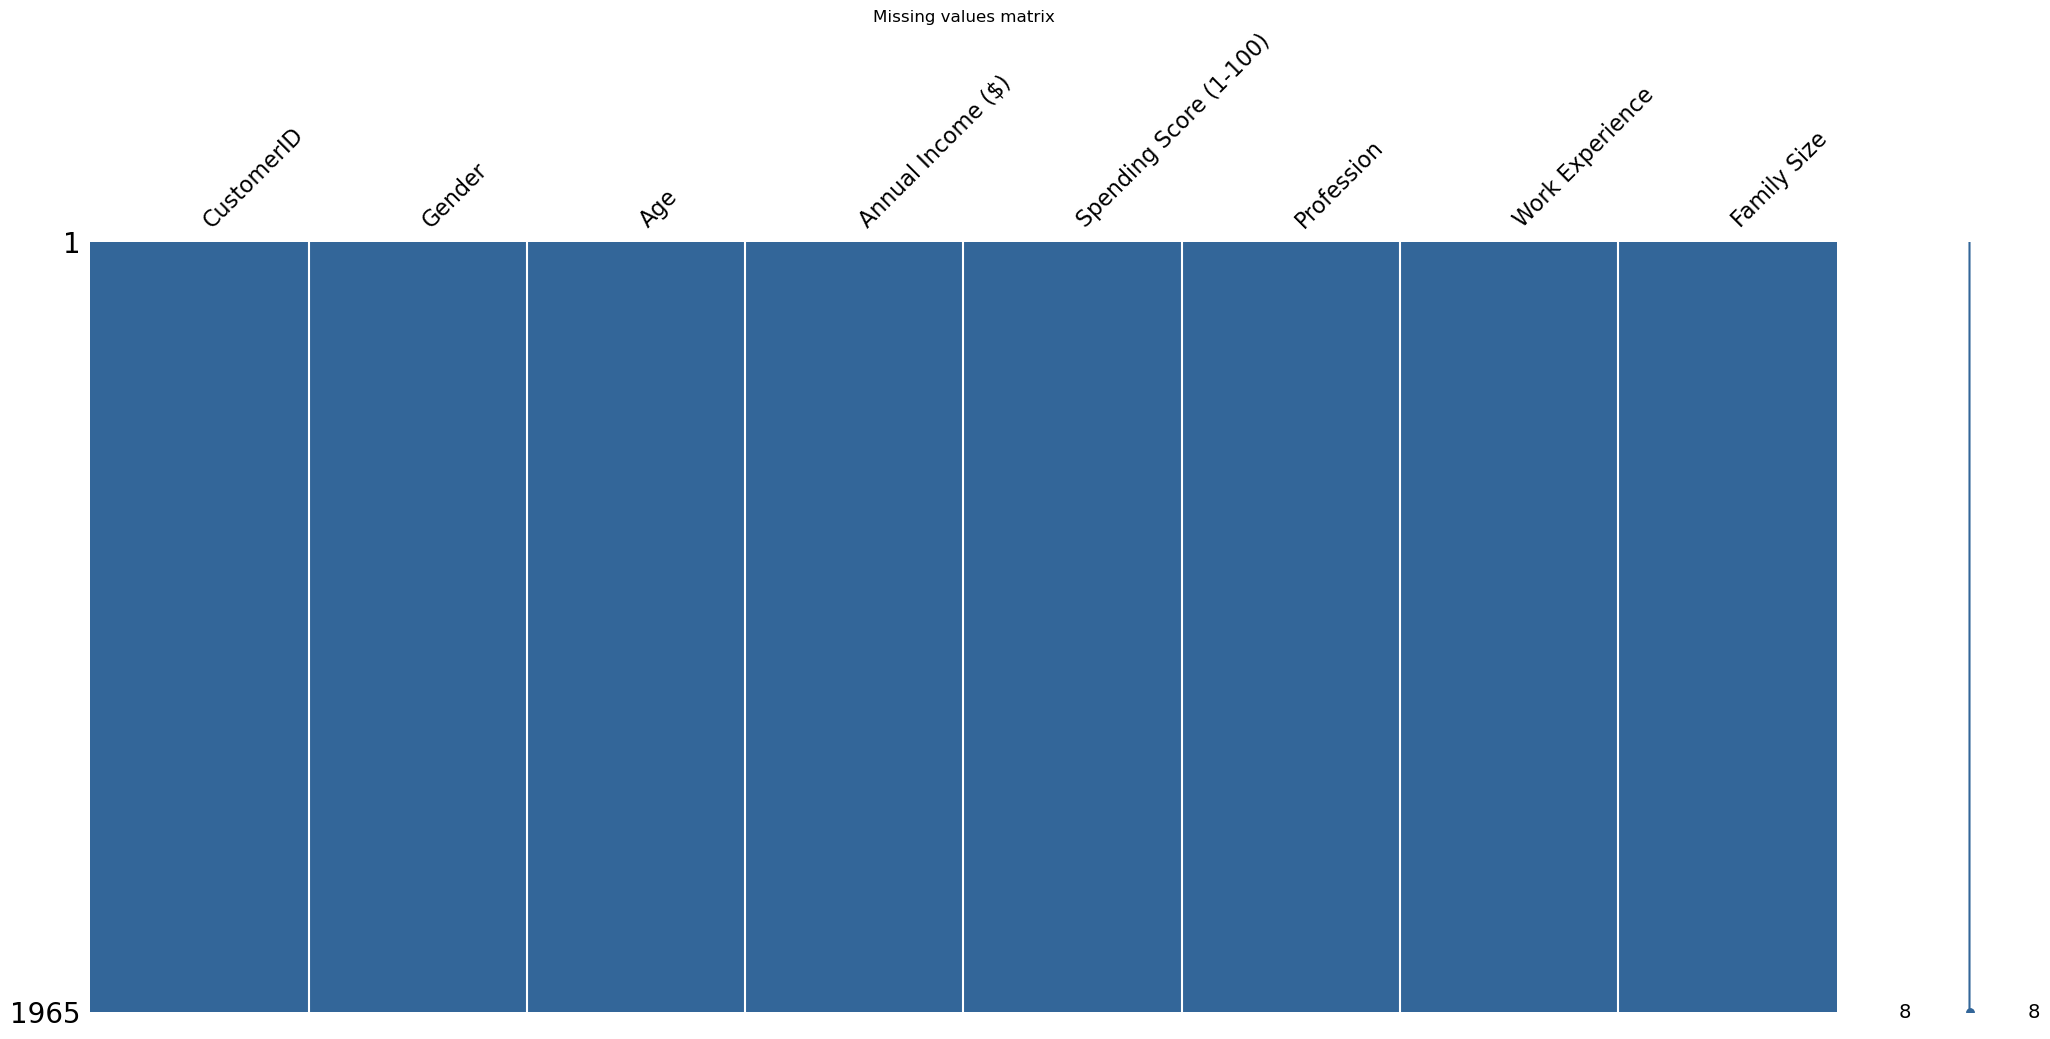

In [88]:
null_counts = df.isnull().sum()
max_null_column = null_counts.idxmax()
max_null_value = null_counts.max()

print(f"Null Column => {max_null_column}: {max_null_value}")

plt.figure(figsize=(16, 6))
msno.matrix(
    df,
    color=(0.2, 0.4, 0.6)
)

plt.title("Missing values matrix")
plt.savefig("missing_values_matrix_before.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
df = df.dropna()

<Figure size 1600x600 with 0 Axes>

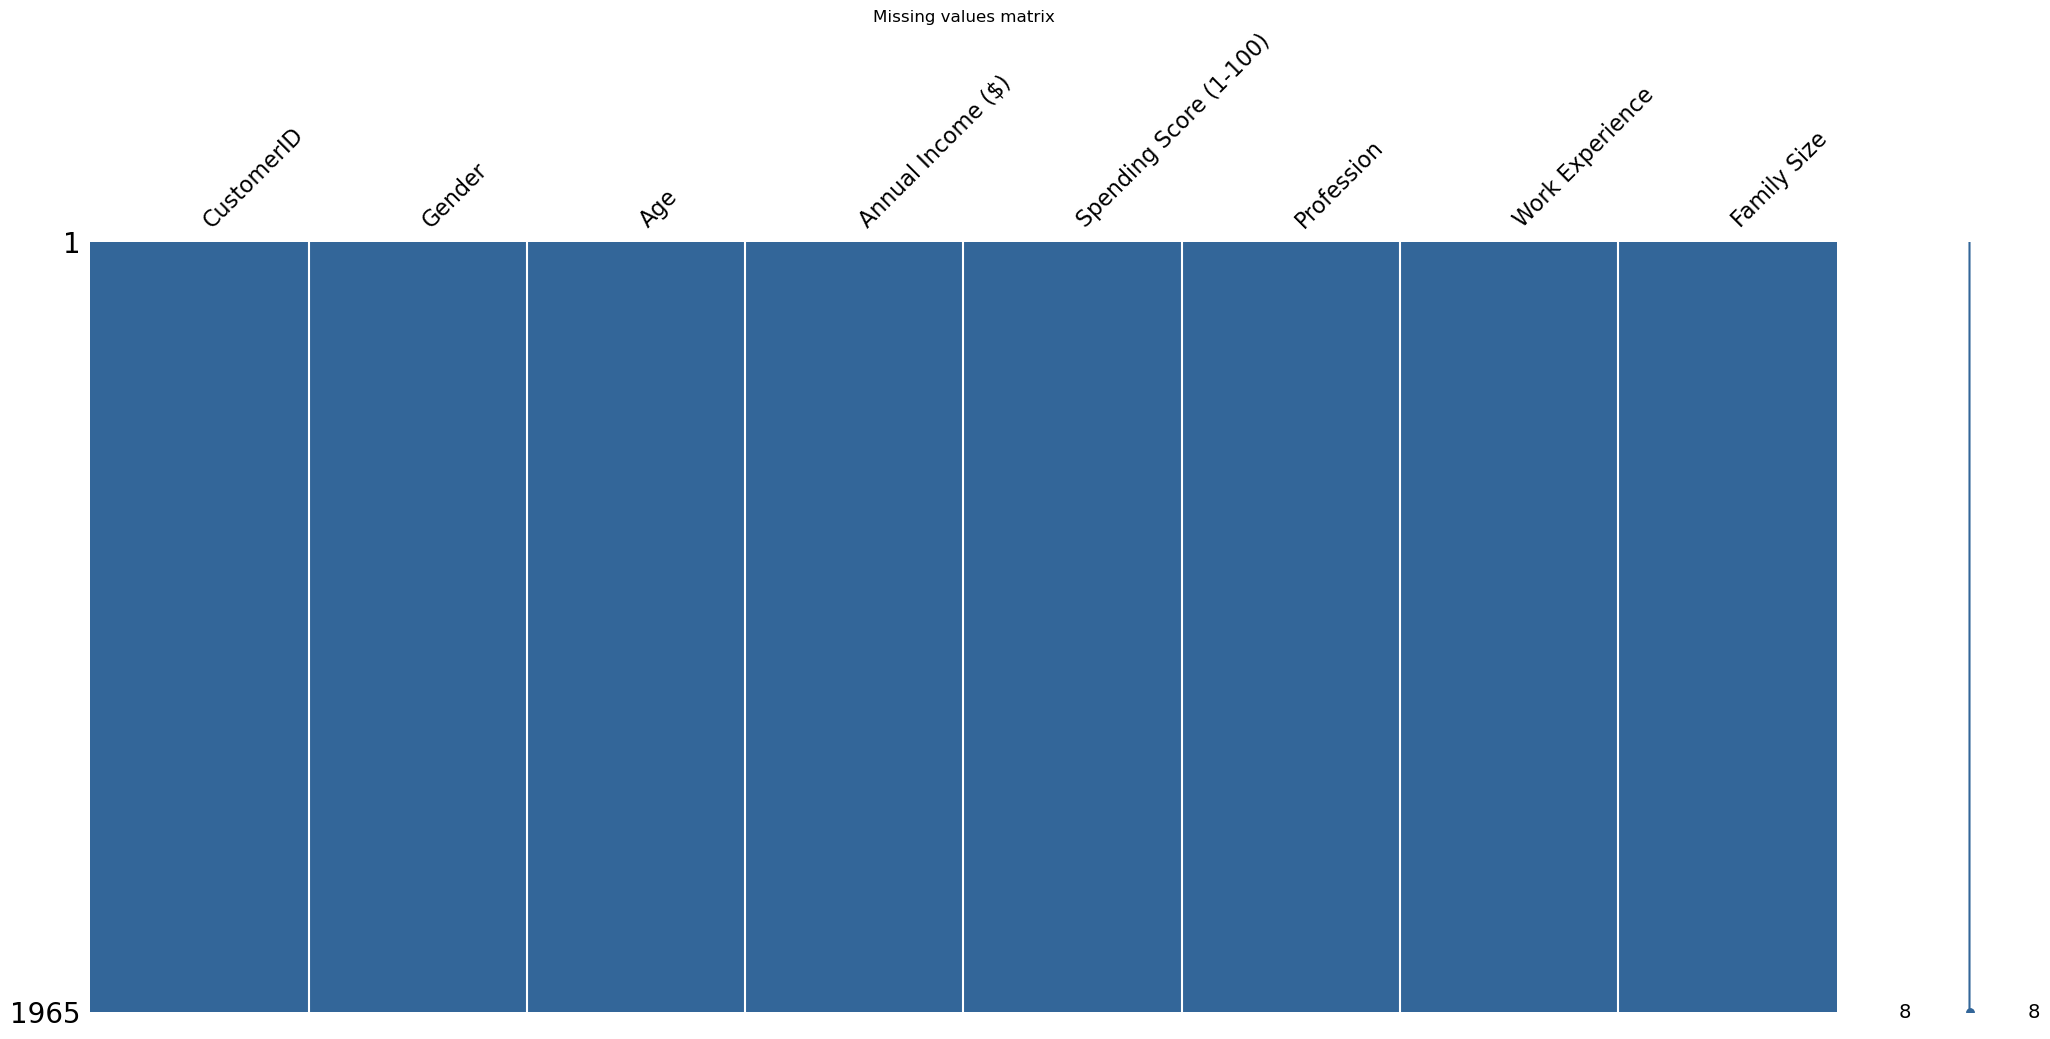

In [9]:
plt.figure(figsize=(16, 6))
msno.matrix(
    df,
    color=(0.2, 0.4, 0.6)
)

plt.title("Missing values matrix")
plt.show()

In [10]:
df_copy = df.copy()

In [11]:
df_copy.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


### Customer clustering

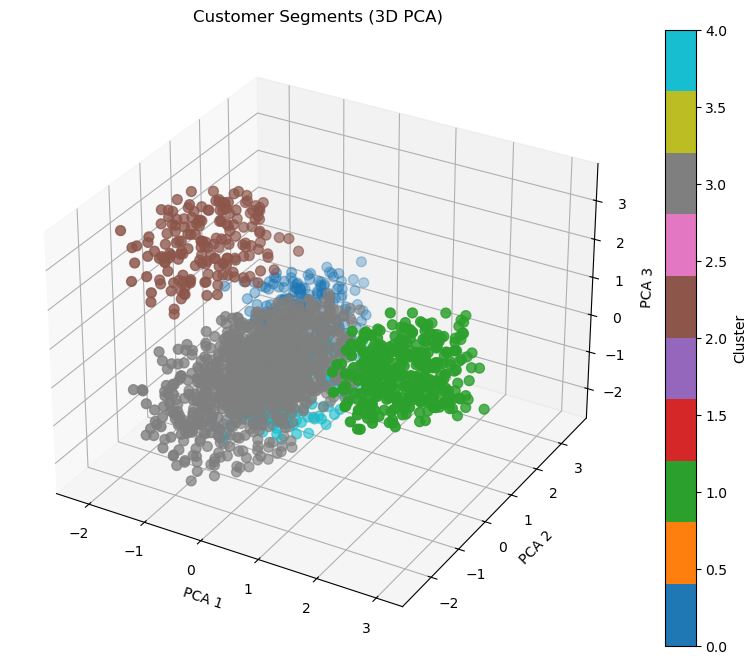

               Age  Annual Income ($)  Spending Score (1-100)  Family Size
Cluster                                                                   
0        51.162393      110650.333333               52.940171     3.888889
1        47.843658      112574.041298               50.516224     3.905605
2        55.094972      111161.240223               48.966480     3.581006
3        48.014151      109434.895283               51.374528     3.680189
4        46.601307      113770.130719               49.901961     3.967320


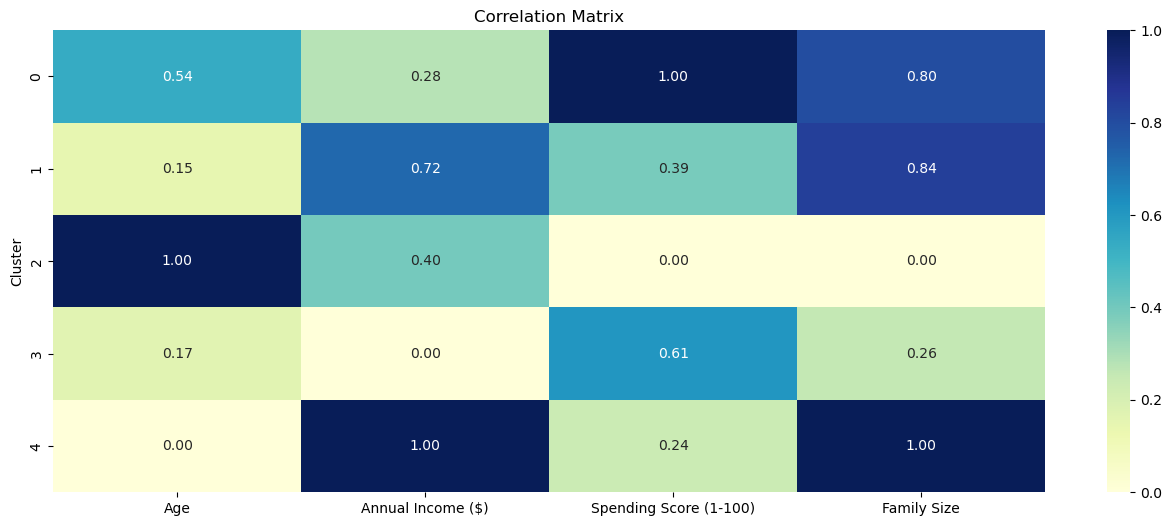

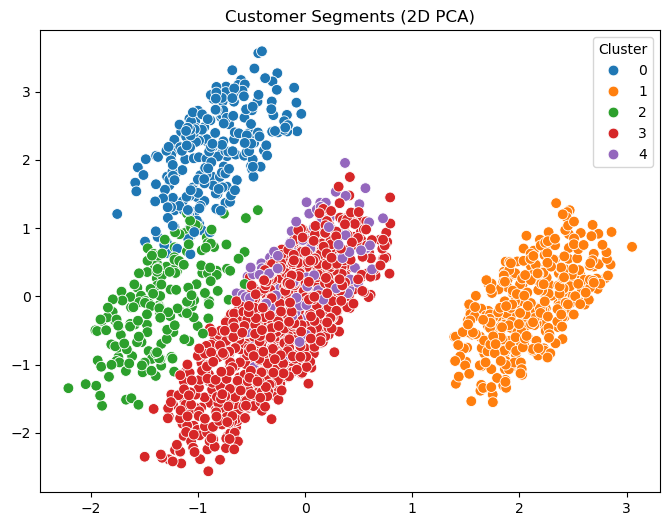


Count of customers in each claster
Cluster
3    1060
1     339
0     234
2     179
4     153
Name: count, dtype: int64


In [90]:
df2 = df_copy[['Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Family Size', 'Profession', 'Gender']].copy()

df2 = pd.get_dummies(df2, columns=['Profession', 'Gender'], drop_first=True)

scaler = StandardScaler()
scaled = scaler.fit_transform(df2)

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled)

df_copy = df_copy.copy()
df_copy['Cluster'] = clusters

pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    pca_result_3d[:,0],
    pca_result_3d[:,1],
    pca_result_3d[:,2],
    c=df_copy['Cluster'],
    cmap='tab10',
    s=50
)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.title('Customer Segments (3D PCA)')
plt.colorbar(scatter, label='Cluster')
plt.savefig("k_means.png", dpi=300, bbox_inches='tight')

plt.show()

cluster_summary = df_copy.groupby('Cluster')[['Age','Annual Income ($)','Spending Score (1-100)','Family Size']].mean()
print(cluster_summary)

cluster_summary_scaled = cluster_summary.apply(lambda x: (x - x.min()) / (x.max() - x.min()))
plt.figure(figsize=(16, 6))
sns.heatmap(cluster_summary_scaled, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Correlation Matrix')
plt.savefig("corr_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

pca_2d = PCA(n_components=2)
pca_result_2d = pca_2d.fit_transform(scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result_2d[:,0], y=pca_result_2d[:,1], hue=df_copy['Cluster'], palette='tab10', s=60)
plt.title('Customer Segments (2D PCA)')
plt.savefig("k_means.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nCount of customers in each claster")
print(df_copy['Cluster'].value_counts())

### RFM Customer Analysis

- Who are your best customers?
- Which customers are at risk of churning?
- Who has the potential to become more valuable?
- Which customers can be effectively retained?
- Who is most likely to respond to engagement campaigns?

In [13]:
rfm_df = pd.DataFrame()
rfm_df['CustomerID'] = df['CustomerID']
rfm_df['Recency'] = df['Family Size']
rfm_df['Frequency'] = df['Work Experience']
rfm_df['Monetary'] = df['Annual Income ($)'] * (df['Spending Score (1-100)'] / 100)

In [14]:
rfm_df.rename(columns={
    'Recency': 'Recency_Proxy',
    'Frequency': 'Frequency_Proxy',
    'Monetary': 'Monetary_Value'
}, inplace=True)

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
rfm_df[['Recency_Proxy', 'Frequency_Proxy', 'Monetary_Value']] = scaler.fit_transform(
    rfm_df[['Recency_Proxy', 'Frequency_Proxy', 'Monetary_Value']]
)

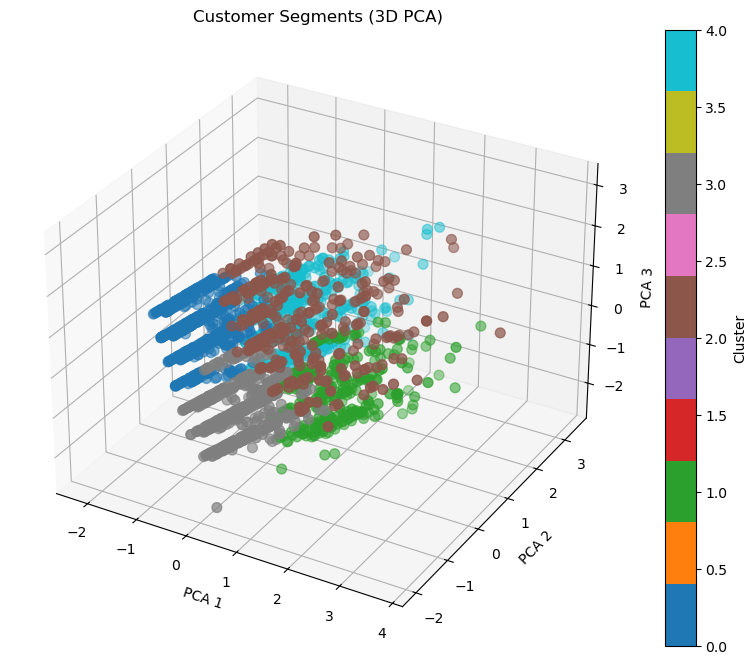

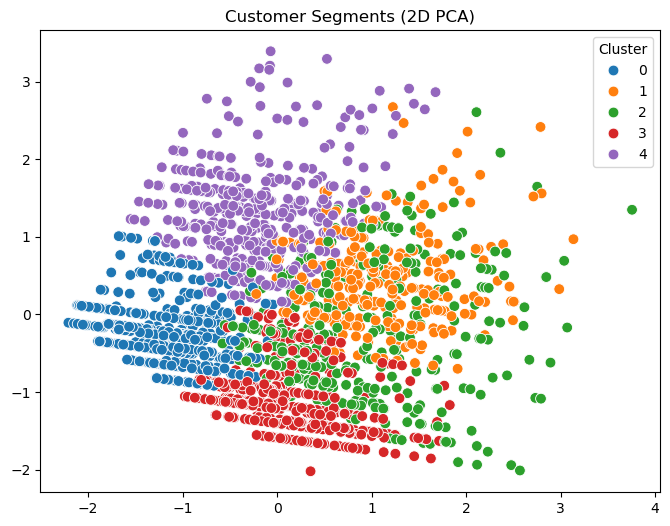

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df3 = rfm_df.drop('CustomerID', axis=1)

scaler = StandardScaler()
scaled = scaler.fit_transform(df3)

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled)

df_copy = df.copy()
df_copy['Cluster'] = clusters

pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    pca_result_3d[:,0],
    pca_result_3d[:,1],
    pca_result_3d[:,2],
    c=df_copy['Cluster'],
    cmap='tab10',
    s=50
)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.title('Customer Segments (3D PCA)')
plt.colorbar(scatter, label='Cluster')
plt.show()

pca_2d = PCA(n_components=2)
pca_result_2d = pca_2d.fit_transform(scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result_2d[:,0], y=pca_result_2d[:,1], hue=df_copy['Cluster'], palette='tab10', s=60)
plt.title('Customer Segments (2D PCA)')
plt.savefig("rfm_pca.png", dpi=300, bbox_inches='tight')
plt.show()

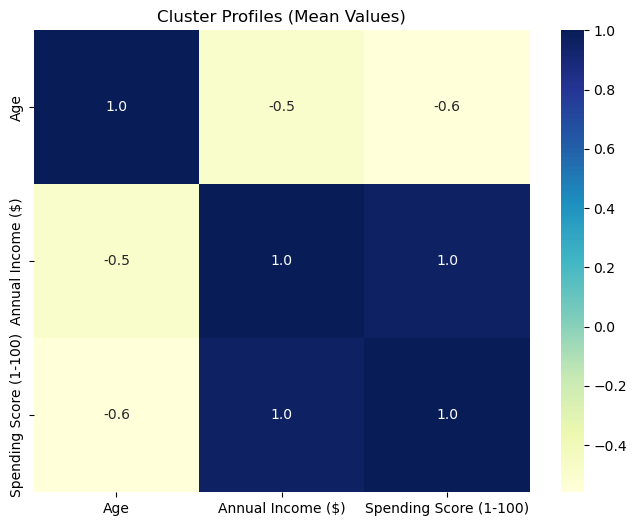

In [92]:
rfm_analys = df_copy.groupby('Cluster')[['Age','Annual Income ($)','Spending Score (1-100)']].mean().corr()

plt.figure(figsize=(8,6))
sns.heatmap(rfm_analys, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Cluster Profiles (Mean Values)")
plt.savefig("rfm_corr_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
rfm_analys

,Age,Annual Income ($),Spending Score (1-100)
Age,1.000000,-0.489637,-0.559225
Annual Income ($),-0.489637,1.000000,0.960224
Spending Score (1-100),-0.559225,0.960224,1.000000


### Exploratory Data Analysis (EDA)

In [19]:
df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


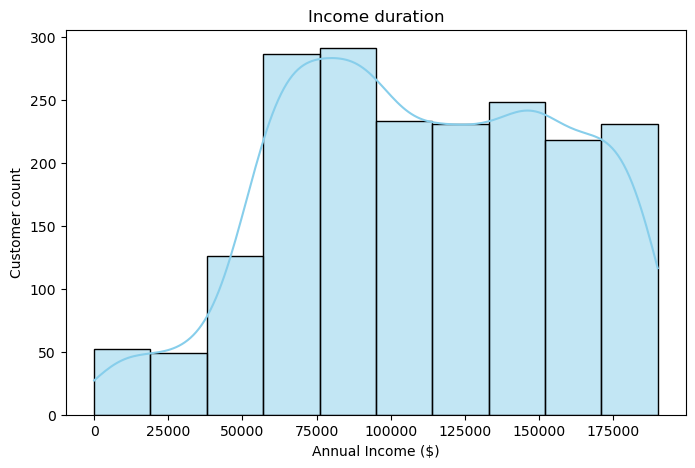

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_copy['Annual Income ($)'], bins=10, kde=True, color='skyblue')
plt.title('Income duration')
plt.xlabel('Annual Income ($)')
plt.ylabel('Customer count')
plt.savefig("income_duration.png", dpi=300, bbox_inches='tight')
plt.show()

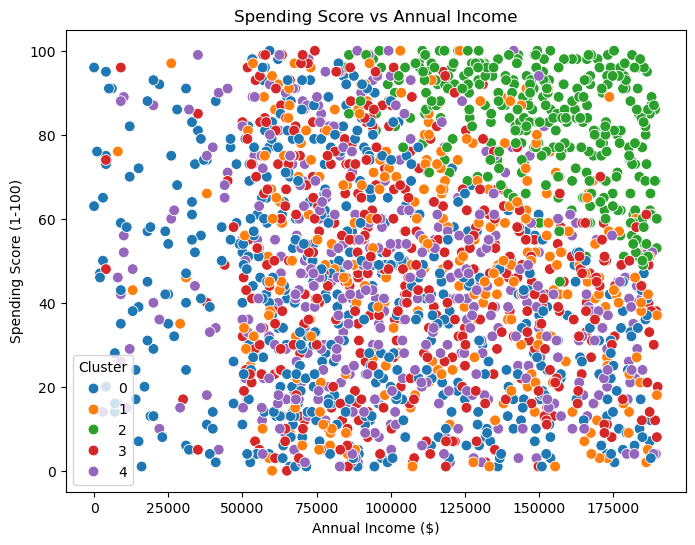

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income ($)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    data=df_copy, 
    palette='tab10', 
    s=60
)
plt.title('Spending Score vs Annual Income')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.show()

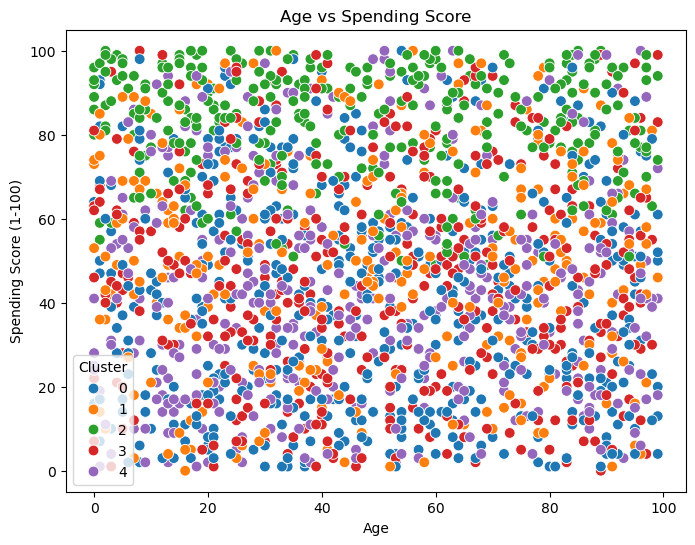

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Age',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df_copy,
    palette='tab10',
    s=60
)
plt.title('Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_17540\2634629368.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profession', y='Annual Income ($)', data=df_copy, palette='Set3')


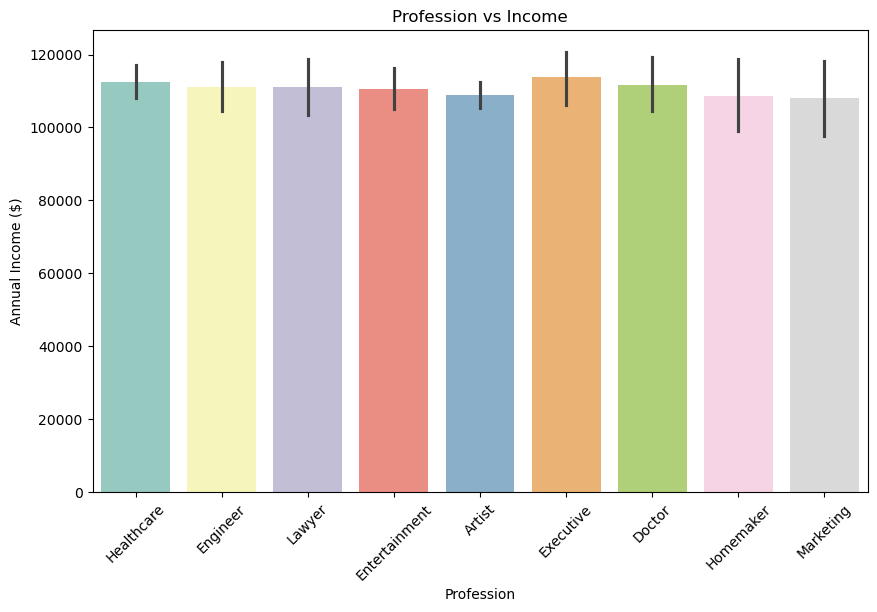

C:\Users\User\AppData\Local\Temp\ipykernel_17540\2634629368.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profession', y='Spending Score (1-100)', data=df_copy, palette='Set3')


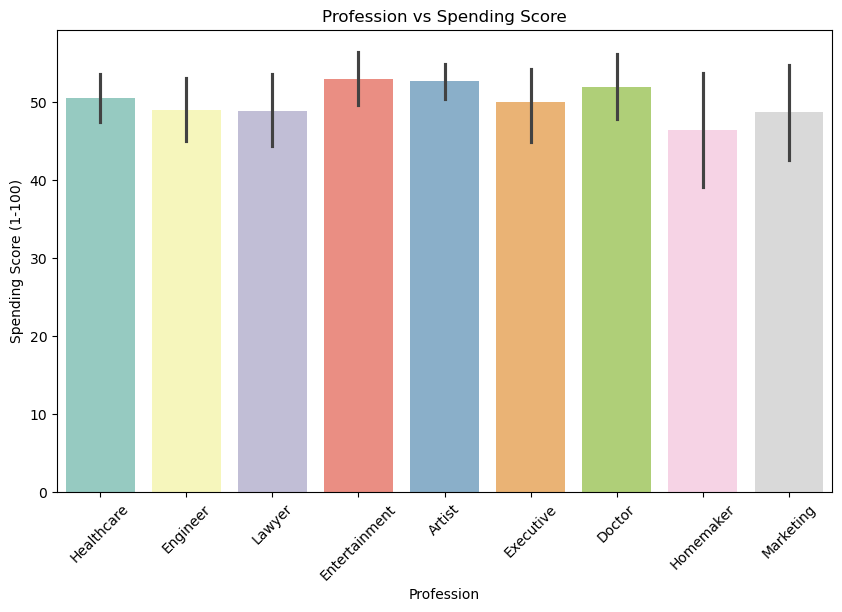

In [94]:
plt.figure(figsize=(10,6))
sns.barplot(x='Profession', y='Annual Income ($)', data=df_copy, palette='Set3')
plt.title('Profession vs Income')
plt.xticks(rotation=45)
plt.savefig("profession_vs_income.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x='Profession', y='Spending Score (1-100)', data=df_copy, palette='Set3')
plt.title('Profession vs Spending Score')
plt.xticks(rotation=45)
plt.savefig("profession_vs_spending.png", dpi=300, bbox_inches='tight')
plt.show()

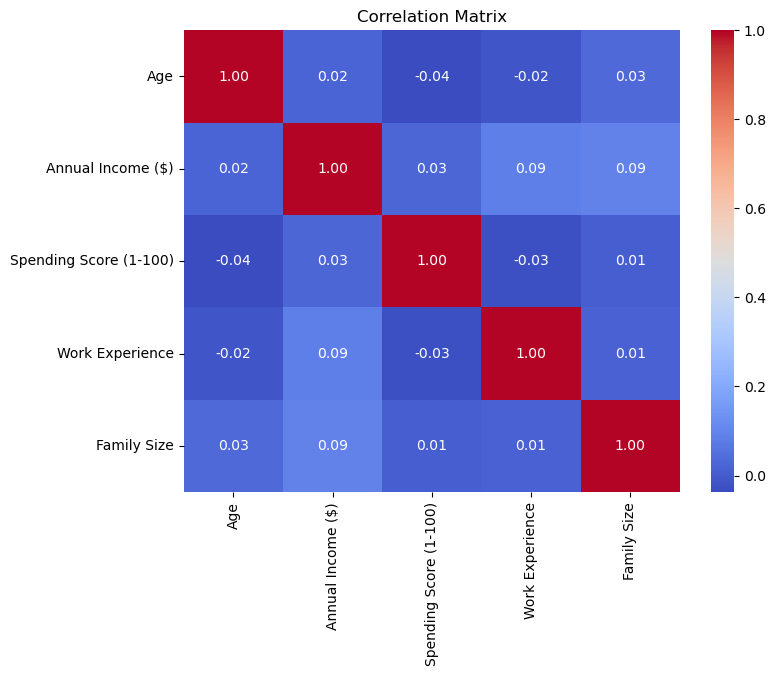

In [58]:
corr = df_copy[['Age','Annual Income ($)','Spending Score (1-100)','Work Experience','Family Size']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

### Gender Distribution

In [30]:
df_copy['Gender'] = df['Gender'].map({
    'Male': 1,
    'Female': 0
})

C:\Users\User\AppData\Local\Temp\ipykernel_17540\450092395.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m_percent = (gender_counts.get(1, 0) / total) * 100
C:\Users\User\AppData\Local\Temp\ipykernel_17540\450092395.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f_percent = (gender_counts.get(0, 0) / total) * 100
C:\Users\User\AppData\Local\Temp\ipykernel_17540\450092395.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


-- Gender distribution --
Male:   40.66% (799 customers)
Female: 59.34% (1166 customers)


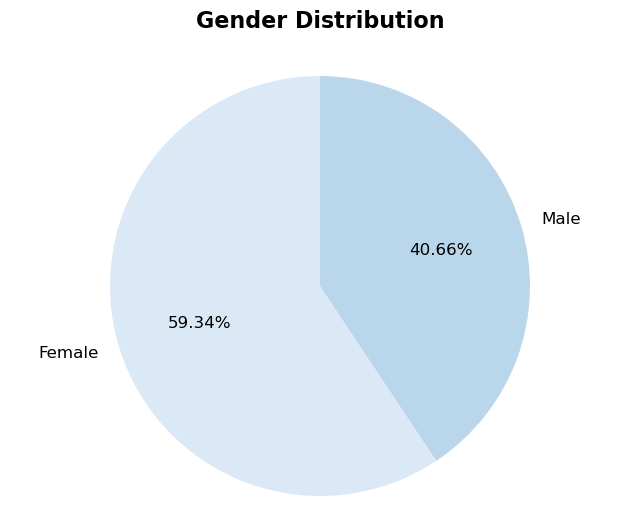

In [95]:
gender_counts = df_copy['Gender'].value_counts().sort_index()
labels = ['Female', 'Male']
sizes = gender_counts.values
colors = sns.color_palette('Blues')[0:2]

total = len(df_copy)
m_percent = (gender_counts.get(1, 0) / total) * 100
f_percent = (gender_counts.get(0, 0) / total) * 100

print("-- Gender distribution --")
print(f"Male:   {m_percent:.2f}% ({gender_counts.get(1, 0)} customers)")
print(f"Female: {f_percent:.2f}% ({gender_counts.get(0, 0)} customers)")

plt.figure(figsize=(8, 6))
plt.pie(sizes, 
        labels=labels, 
        colors=colors, 
        autopct='%1.2f%%',
        startangle=90,
        textprops={'fontsize': 12})

plt.axis('equal')
plt.title('Gender Distribution', fontsize=16, fontweight='bold', pad=20)
plt.savefig("gender_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [75]:
gender_means = df_copy.groupby('Gender')[['Annual Income ($)', 'Spending Score (1-100)']].mean()

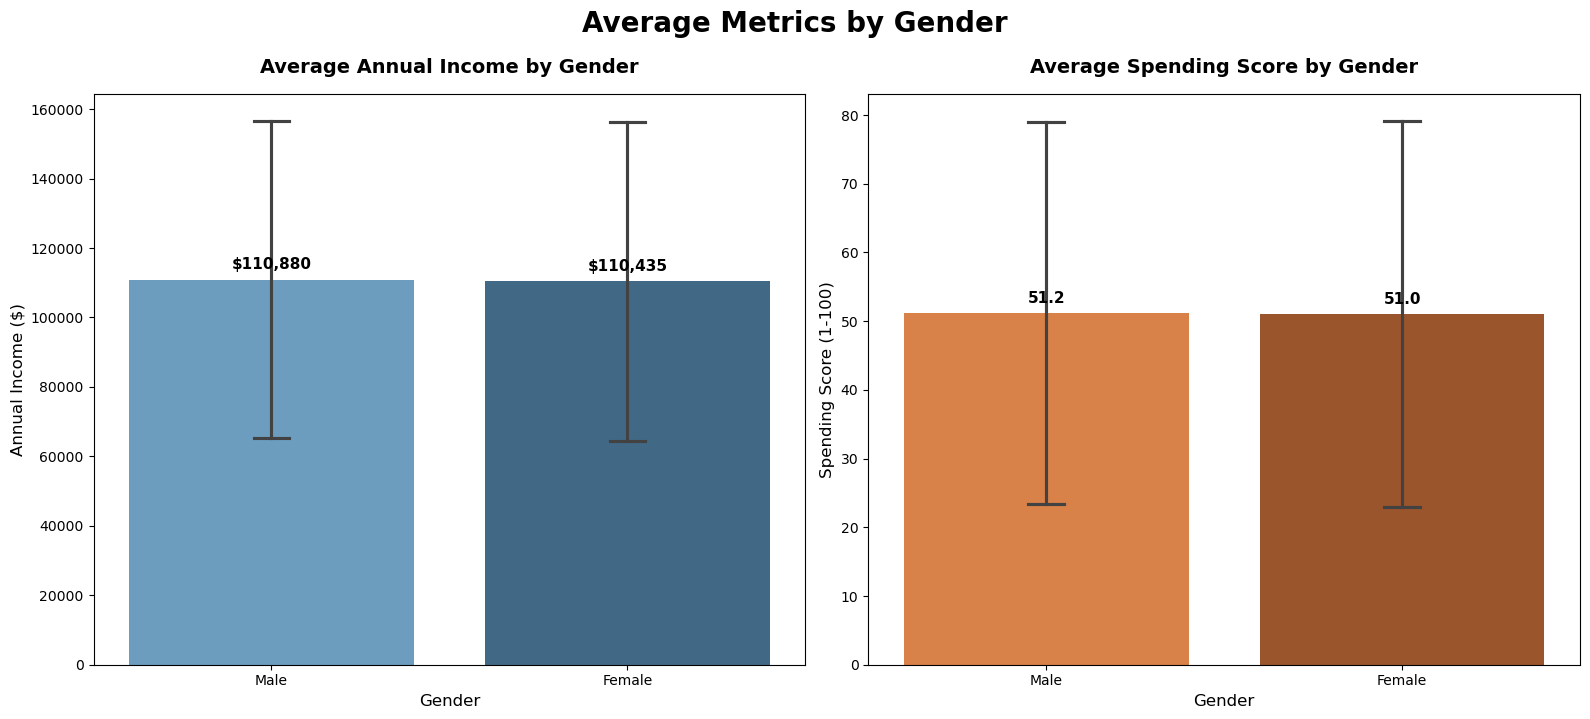

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
fig.suptitle('Average Metrics by Gender', fontsize=20, fontweight='bold', y=1.02)

sns.barplot(
    data=df_copy,
    x='Gender',
    y='Annual Income ($)',
    hue='Gender',
    palette='Blues_d',
    legend=False,
    errorbar='sd',
    capsize=0.1,
    ax=axes[0]
)

axes[0].set_title('Average Annual Income by Gender', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Annual Income ($)', fontsize=12)

for i, bar in enumerate(axes[0].patches):
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height + height*0.02,
        f'${height:,.0f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

sns.barplot(
    data=df_copy,
    x='Gender',
    y='Spending Score (1-100)',
    hue='Gender',
    palette='Oranges_d',
    legend=False,
    errorbar='sd',
    capsize=0.1,
    ax=axes[1]
)

axes[1].set_title('Average Spending Score by Gender', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=12)

for i, bar in enumerate(axes[1].patches):
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig("avg_metrics_gender.png", dpi=300, bbox_inches='tight')
plt.show()

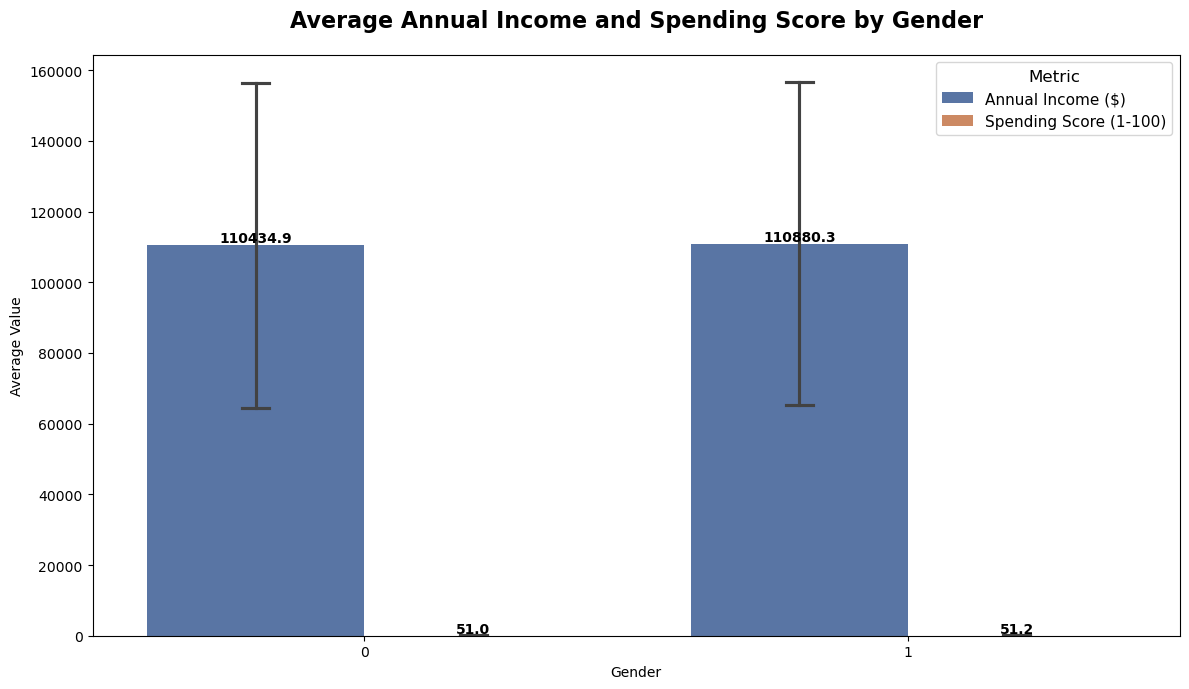

In [84]:
df_plot = df_copy.melt(id_vars='Gender',
                       value_vars=['Annual Income ($)', 'Spending Score (1-100)'],
                       var_name='Metric',
                       value_name='Value')

plt.figure(figsize=(12, 7))
sns.barplot(data=df_plot,
            x='Gender',
            y='Value',
            hue='Metric',
            palette=['#4c72b0', '#dd8452'],
            errorbar='sd',
            capsize=0.1)

plt.title('Average Annual Income and Spending Score by Gender', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Average Value')
plt.xlabel('Gender')
plt.legend(title='Metric', title_fontsize=12, fontsize=11)

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt=lambda x: f'${x:,.0f}' if 'Income' in str(container) else f'{x:.1f}',
                        fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()